In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA notebook ready")

EDA notebook ready


In [62]:
import os
import hopsworks
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

In [54]:
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="aqi_project_10pearls",
    api_key_value=HOPSWORKS_KEY
)

fs = project.get_feature_store()

fg = fs.get_feature_group(
    name="aqi_features",
    version=1
)

df = fg.read()
df.head()

2026-05-15 17:01:59,889 INFO: Closing external client and cleaning up certificates.
2026-05-15 17:01:59,899 INFO: Connection closed.
2026-05-15 17:01:59,900 INFO: Initializing external client
2026-05-15 17:01:59,900 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-15 17:02:02,124 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32913
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (30.63s) 


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_rolling_6h,aqi_rolling_24h,target_aqi_3h,target_aqi_24h,target_aqi_72h
0,2026-05-04 03:00:00+00:00,Karachi,125.0,29.99,85.19,110.59,0.36,0.53,128.01,32.6,...,0.707107,0.707107,5.000000e-01,-8.660254e-01,0.0,150.0,139.583333,125.0,125.0,125.0
1,2025-12-25 05:00:00+00:00,Karachi,125.0,44.68,79.67,122.92,1.75,10.03,310.01,19.8,...,0.965926,0.258819,-2.449294e-16,1.000000e+00,0.0,125.0,147.916667,175.0,125.0,300.0
2,2025-10-20 15:00:00+00:00,Karachi,125.0,30.25,74.14,95.38,0.17,0.64,130.01,28.1,...,-0.707107,-0.707107,-8.660254e-01,5.000000e-01,0.0,125.0,125.000000,125.0,175.0,300.0
3,2026-03-31 21:00:00+00:00,Karachi,125.0,9.71,28.13,115.39,0.15,0.44,116.11,24.0,...,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.0,125.0,125.000000,125.0,125.0,125.0
4,2025-11-02 00:00:00+00:00,Karachi,175.0,58.80,113.56,99.19,0.10,0.46,180.71,23.1,...,0.000000,1.000000,-5.000000e-01,8.660254e-01,0.0,175.0,227.083333,175.0,300.0,175.0


# Data Summary

In [55]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (8589, 28)
Columns: ['timestamp', 'city', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_change_rate', 'aqi_rolling_6h', 'aqi_rolling_24h', 'target_aqi_3h', 'target_aqi_24h', 'target_aqi_72h']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8589 entries, 0 to 8588
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        8589 non-null   datetime64[us, Etc/UTC]
 1   city             8589 non-null   object                 
 2   aqi              8589 non-null   float64                
 3   pm25             8589 non-null   float64                
 4   pm10             8589 non-null   float64                
 5   o3               8589 non-null   float64                
 6   no2              8589 non-null 

In [56]:
df.isnull().sum().sort_values(ascending=False)

target_aqi_72h     46
target_aqi_24h     21
city                0
target_aqi_3h       0
aqi_rolling_24h     0
aqi_rolling_6h      0
aqi_change_rate     0
month_cos           0
month_sin           0
hour_cos            0
hour_sin            0
is_weekend          0
month               0
day_of_week         0
timestamp           0
wind_deg            0
wind_speed          0
pressure            0
humidity            0
temp                0
co                  0
so2                 0
no2                 0
o3                  0
pm10                0
pm25                0
aqi                 0
hour                0
dtype: int64

In [57]:
df_clean = df.dropna(subset=["target_aqi_24h", "target_aqi_72h"])

print("Original shape:", df.shape)
print("After dropping missing target rows:", df_clean.shape)

Original shape: (8589, 28)
After dropping missing target rows: (8543, 28)


In [58]:
print("Original rows:", df.shape[0])
print("Clean rows:", df_clean.shape[0])
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

print("Original columns:", df.shape[1])
print("Clean columns:", df_clean.shape[1])

Original rows: 8589
Clean rows: 8543
Rows dropped: 46
Original columns: 28
Clean columns: 28


In [59]:
df_clean.isnull().sum().sort_values(ascending=False)

timestamp          0
city               0
target_aqi_24h     0
target_aqi_3h      0
aqi_rolling_24h    0
aqi_rolling_6h     0
aqi_change_rate    0
month_cos          0
month_sin          0
hour_cos           0
hour_sin           0
is_weekend         0
month              0
day_of_week        0
hour               0
wind_deg           0
wind_speed         0
pressure           0
humidity           0
temp               0
co                 0
so2                0
no2                0
o3                 0
pm10               0
pm25               0
aqi                0
target_aqi_72h     0
dtype: int64

# AQI Stats

In [60]:
df["aqi"].describe()

count    8589.000000
mean      139.098149
std        63.890196
min        25.000000
25%       125.000000
50%       125.000000
75%       175.000000
max       300.000000
Name: aqi, dtype: float64

# AQI Distribution

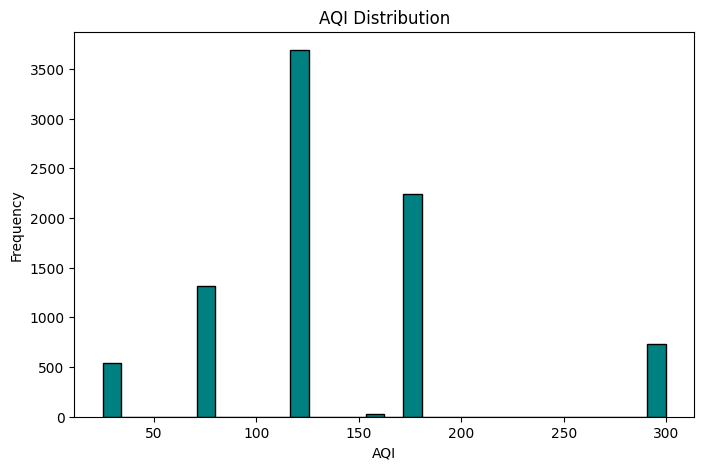

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["aqi"].dropna(), bins=30, color="teal", edgecolor="black")
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# AQI category count

2026-05-15 17:02:37,780 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



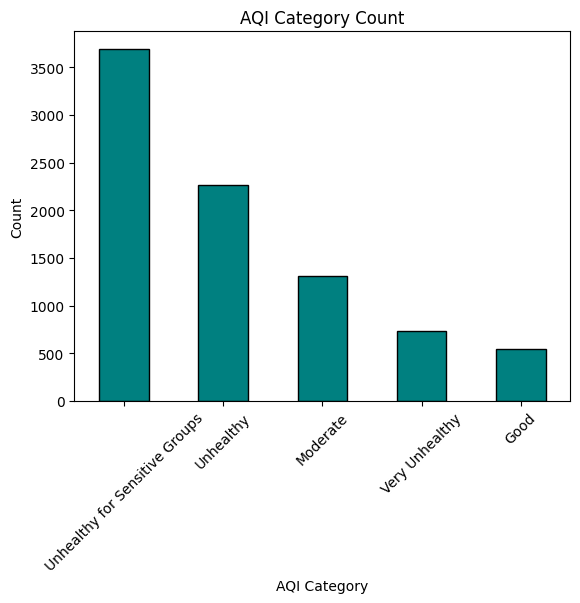

In [63]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df_clean["aqi_category"] = df_clean["aqi"].apply(aqi_category)

df_clean["aqi_category"].value_counts().plot(kind="bar", color="teal", edgecolor="black")
plt.title("AQI Category Count")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# AQI by day of week

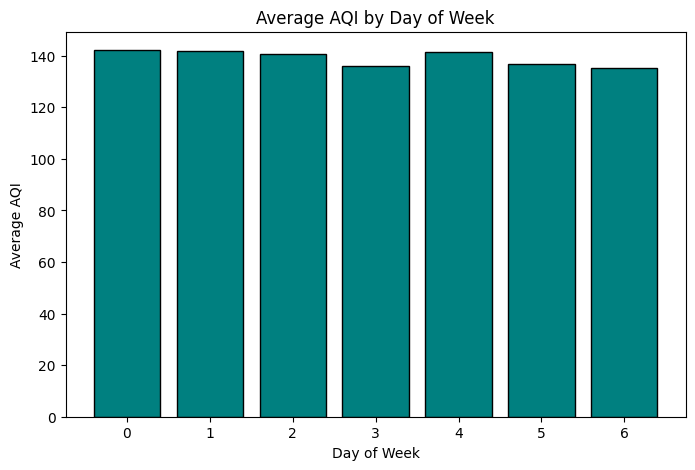

In [64]:
day_aqi = df_clean.groupby("day_of_week")["aqi"].mean()

plt.figure(figsize=(8,5))
plt.bar(day_aqi.index, day_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.show()

# AQI Trend Over Time

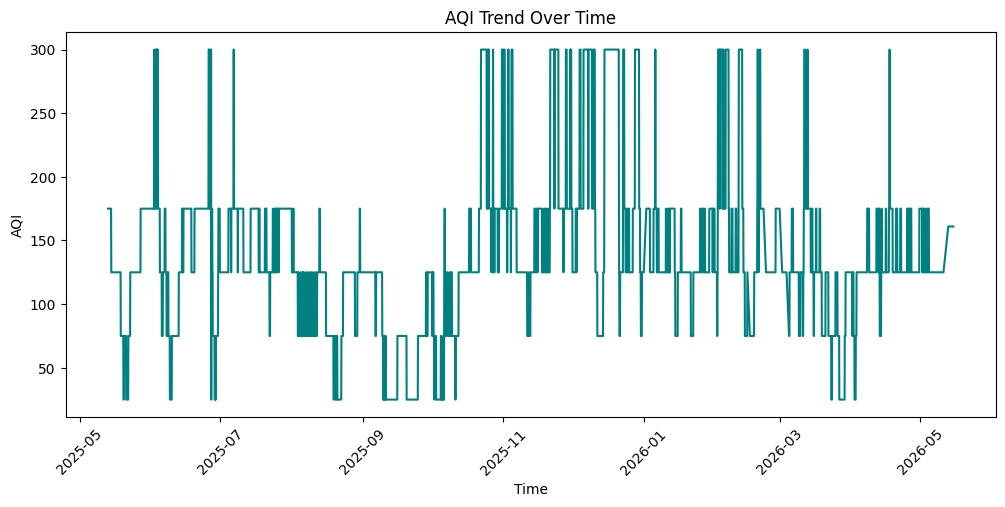

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], color="teal")
plt.title("AQI Trend Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap

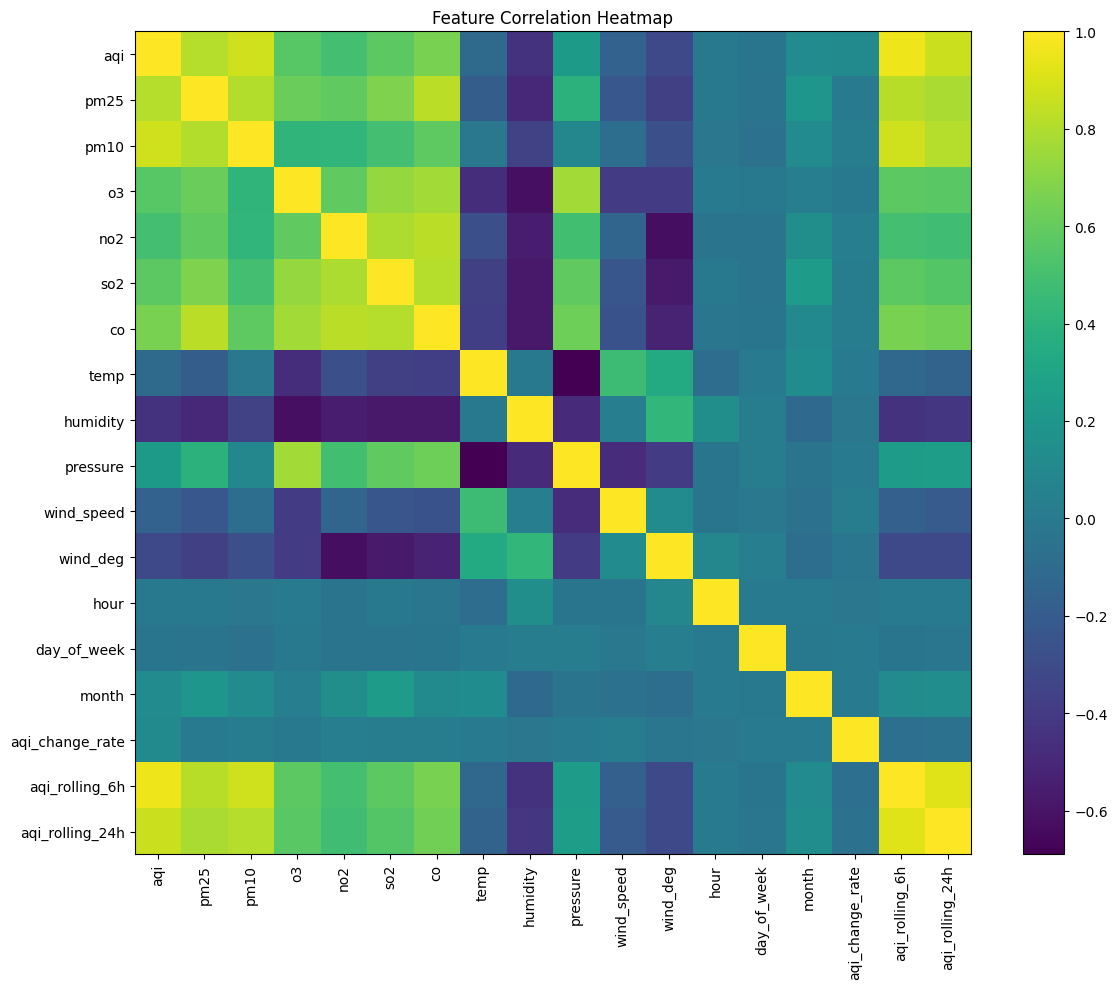

In [46]:
corr_cols = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [69]:
corr_with_aqi = df_clean.corr(numeric_only=True)["aqi"].sort_values(ascending=False)
corr_with_aqi

aqi                1.000000
aqi_rolling_6h     0.959165
target_aqi_3h      0.918424
pm10               0.879202
aqi_rolling_24h    0.866308
pm25               0.812825
co                 0.658889
target_aqi_24h     0.658011
so2                0.575942
o3                 0.561982
no2                0.495915
target_aqi_72h     0.363102
month_cos          0.231287
pressure           0.231112
month              0.123016
month_sin          0.119705
aqi_change_rate    0.118794
hour_sin           0.013791
hour              -0.006895
is_weekend        -0.031863
hour_cos          -0.033080
day_of_week       -0.033938
temp              -0.106362
wind_speed        -0.155652
wind_deg          -0.317591
humidity          -0.442460
Name: aqi, dtype: float64

# Average AQI by Hour

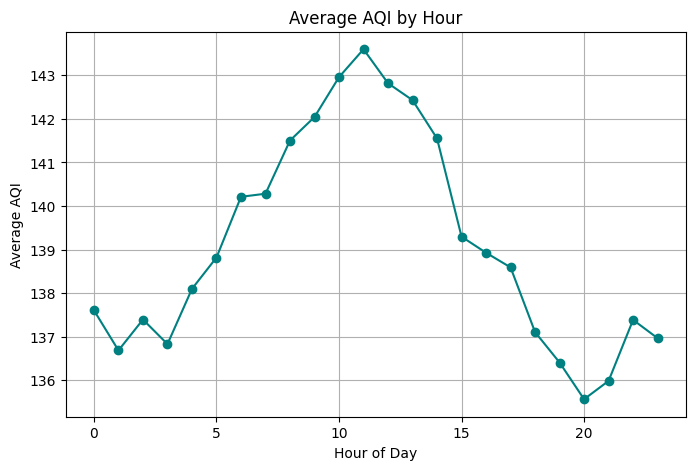

In [47]:
hourly_aqi = df_clean.groupby("hour")["aqi"].mean()
plt.figure(figsize=(8, 5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="teal")
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

# Average AQI by Month

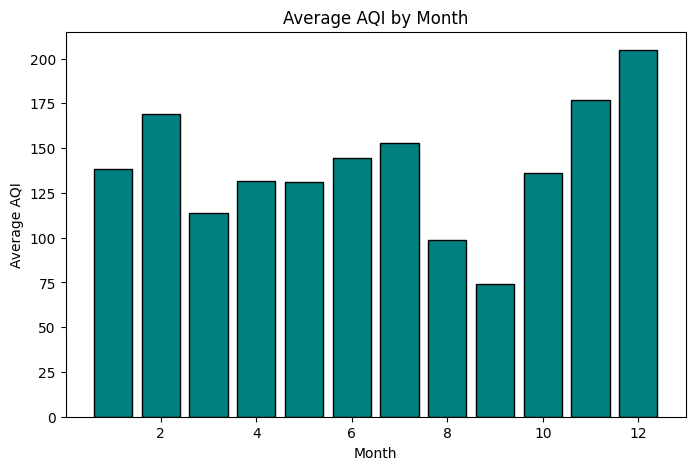

In [48]:
monthly_aqi = df_clean.groupby("month")["aqi"].mean()

plt.figure(figsize=(8, 5))
plt.bar(monthly_aqi.index, monthly_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

# Pollutants vs AQI

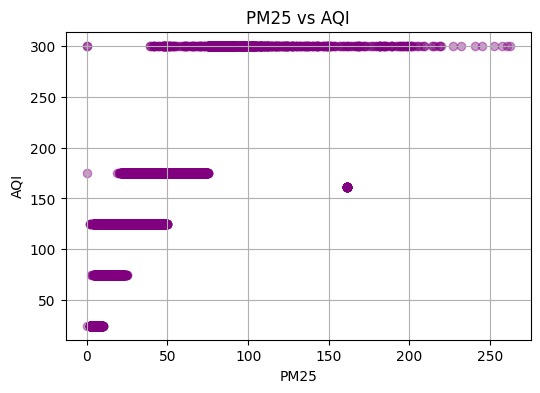

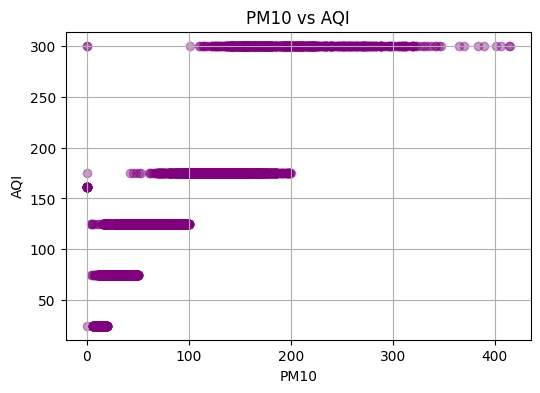

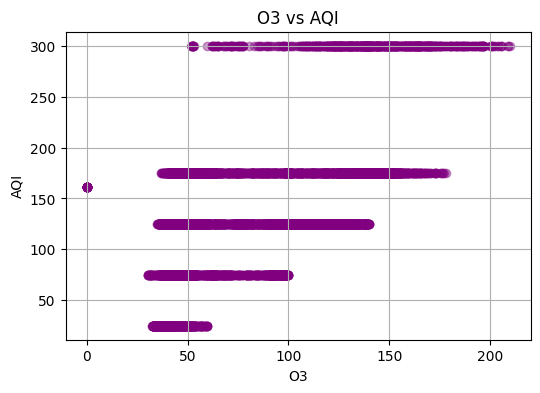

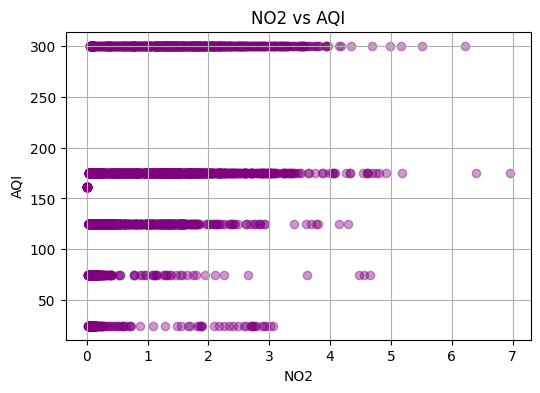

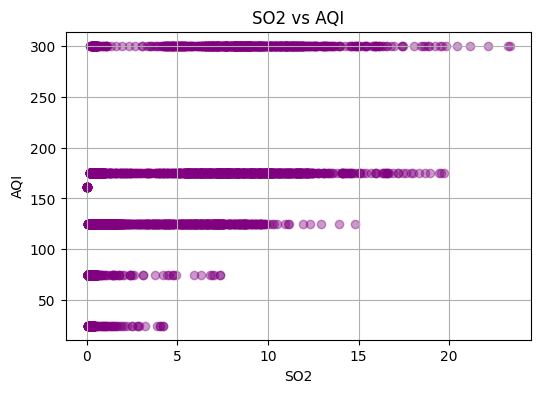

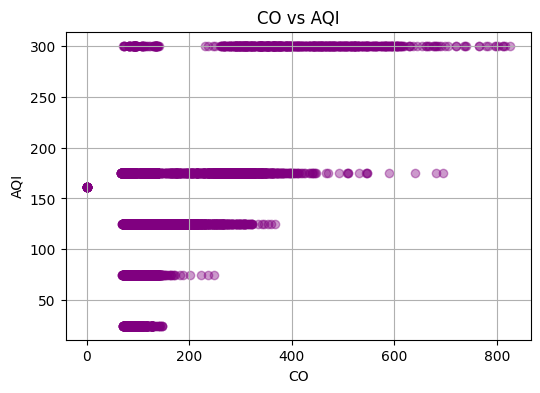

In [49]:
pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

for col in pollutants:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="purple")
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Weather vs AQI

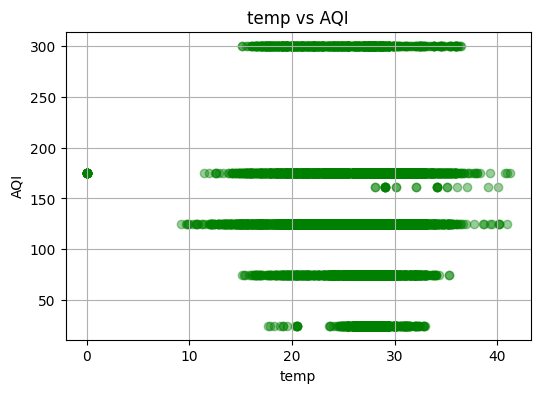

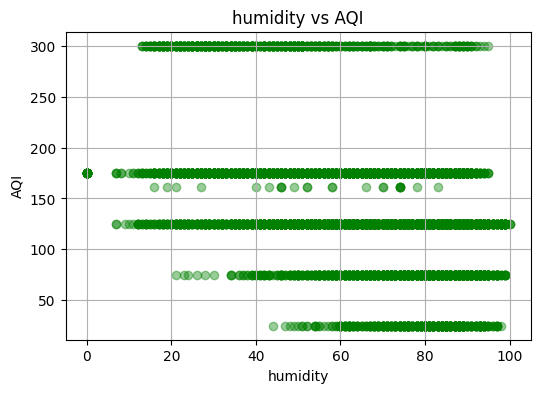

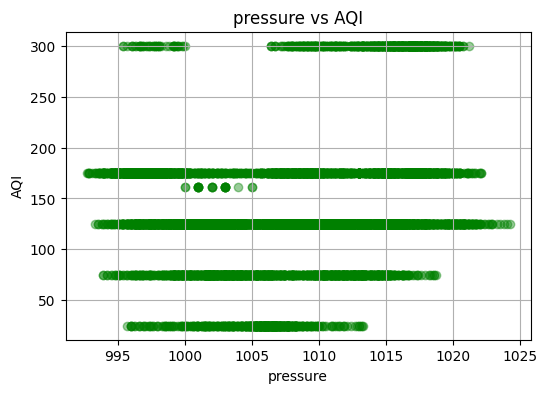

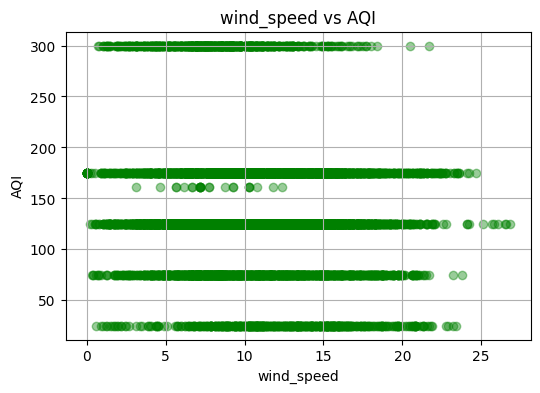

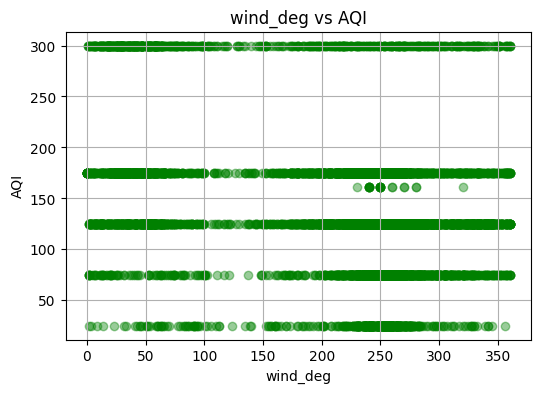

In [66]:
weather_cols = ["temp", "humidity", "pressure", "wind_speed", "wind_deg"]

for col in weather_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="green")
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Outliers

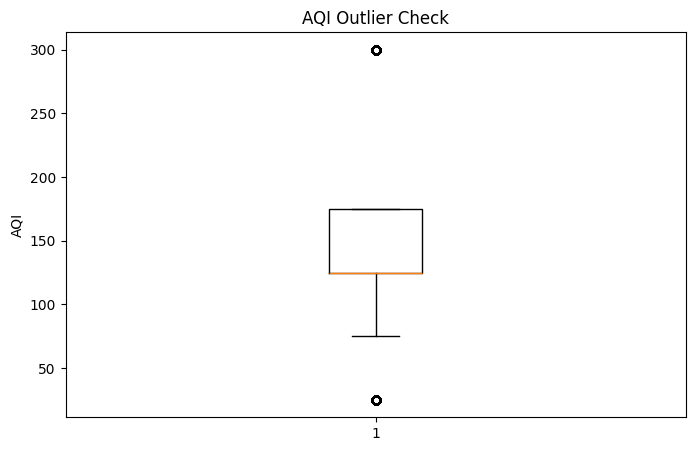

In [67]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["aqi"].dropna())
plt.title("AQI Outlier Check")
plt.ylabel("AQI")
plt.show()

# Rolling AQI trend

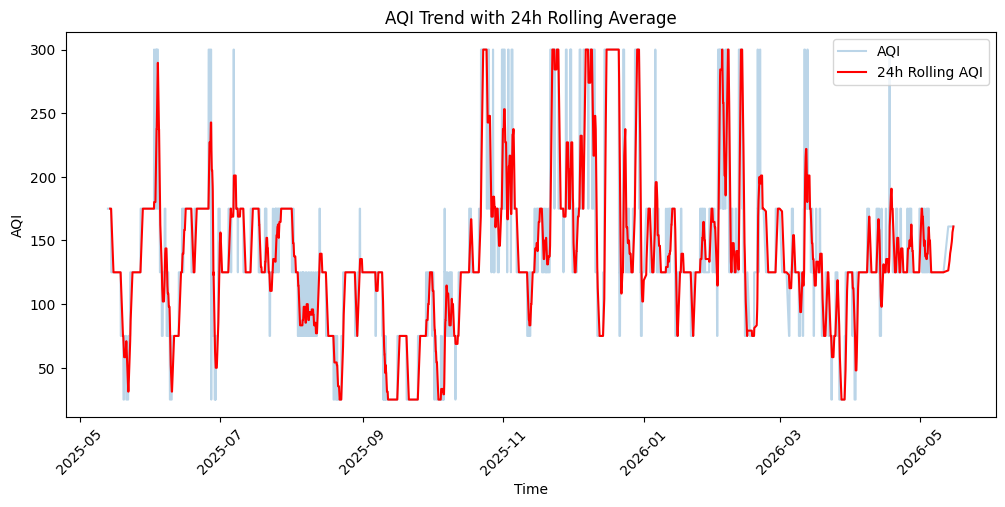

In [68]:
df_sorted = df_clean.sort_values("timestamp")
df_sorted["aqi_rolling_mean"] = df_sorted["aqi"].rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], alpha=0.3, label="AQI")
plt.plot(df_sorted["timestamp"], df_sorted["aqi_rolling_mean"], color="red", label="24h Rolling AQI")
plt.title("AQI Trend with 24h Rolling Average")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## EDA Findings

- The dataset contains 8,589 rows and 28 engineered features.
- After removing rows with missing future target values, 8,543 clean records remained.
- Missing values were mainly present in future target columns, which is expected because the last records do not have future AQI values.
- AQI values vary over time, which makes forecasting meaningful.
- Pollutants such as PM2.5, PM10, O3, NO2, SO2, and CO were analyzed against AQI.
- Weather features such as temperature, humidity, pressure, wind speed, and wind direction were included because weather affects pollution concentration and movement.
- Correlation analysis showed relationships between pollutant features, rolling AQI values, and AQI.
- SHAP feature importance was used in the dashboard to explain which features influence predictions.